In [1]:
import sys, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import (engineer_features, build_model_pipeline,
                           NUMERIC_FEATURES, CATEGORICAL_FEATURES, LOG_TARGET)

PROCESSED_PATH = ROOT / 'data' / 'processed_dataset.csv'
FIGURES = ROOT / 'figures'

df = pd.read_csv(PROCESSED_PATH, parse_dates=['sale_date'])
df = engineer_features(df)

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[FEATURES].copy()
y_log = df[LOG_TARGET].copy()
y_raw = df['sale_price_aud'].copy()

print(f'Loaded {len(df)} records.')

Loaded 120 records.


---
## 4.1  Obtain Cross-Validated Predictions

In [2]:
from sklearn.ensemble import GradientBoostingRegressor

RANDOM_STATE = 42
gb_pipeline = build_model_pipeline(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE,
    ),
    scale_numerics=False,
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
log_preds_cv = cross_val_predict(gb_pipeline, X, y_log, cv=kf)
preds_cv = np.exp(log_preds_cv)  # back to AUD

df['cv_pred_aud'] = preds_cv
df['residual_aud'] = df['sale_price_aud'] - df['cv_pred_aud']
df['abs_error_aud'] = df['residual_aud'].abs()
df['pct_error'] = (df['abs_error_aud'] / df['sale_price_aud'] * 100).round(1)

print(f'Overall CV RMSE: ${np.sqrt(mean_squared_error(y_raw, preds_cv)):,.0f}')
print(f'Residual std: ${df["residual_aud"].std():,.0f}')

Overall CV RMSE: $159,196
Residual std: $159,509


---
## 4.2  Residual Plots

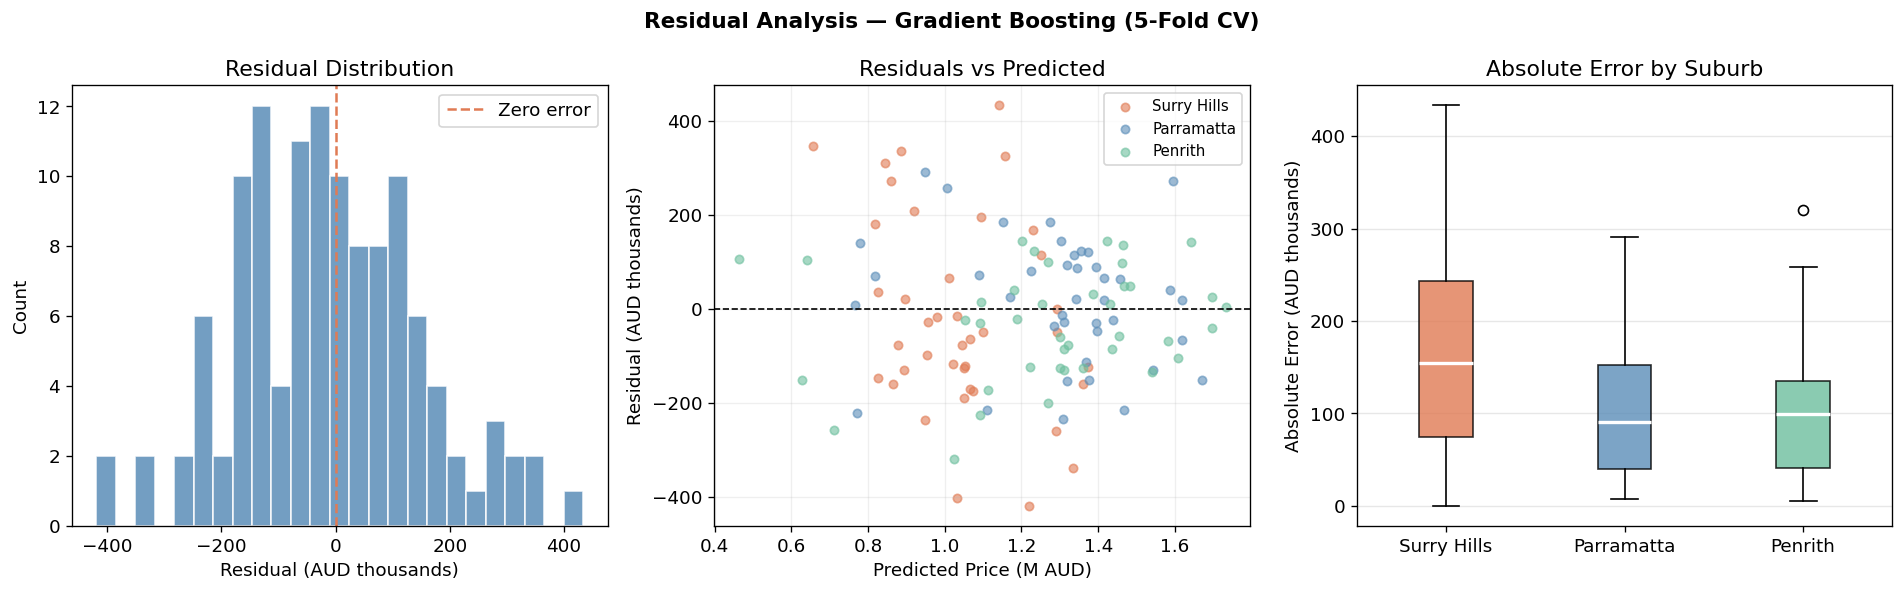

In [3]:
SUBURB_PALETTE = {'Surry Hills': '#E07B54', 'Parramatta': '#5B8DB8', 'Penrith': '#6DBF9E'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual distribution
axes[0].hist(df['residual_aud'] / 1e3, bins=25, color='#5B8DB8', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='#E07B54', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].set_xlabel('Residual (AUD thousands)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution')
axes[0].legend()

# Residuals vs Predicted
for suburb, color in SUBURB_PALETTE.items():
    mask = df['suburb'] == suburb
    axes[1].scatter(df.loc[mask, 'cv_pred_aud'] / 1e6,
                    df.loc[mask, 'residual_aud'] / 1e3,
                    color=color, alpha=0.6, s=25, label=suburb)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Price (M AUD)')
axes[1].set_ylabel('Residual (AUD thousands)')
axes[1].set_title('Residuals vs Predicted')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Absolute error by suburb (box)
data_box = [df.loc[df['suburb'] == s, 'abs_error_aud'].values / 1e3
            for s in ['Surry Hills', 'Parramatta', 'Penrith']]
bp = axes[2].boxplot(data_box, labels=['Surry Hills', 'Parramatta', 'Penrith'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#E07B54', '#5B8DB8', '#6DBF9E']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].set_ylabel('Absolute Error (AUD thousands)')
axes[2].set_title('Absolute Error by Suburb')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Residual Analysis — Gradient Boosting (5-Fold CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'residuals_analysis.png', bbox_inches='tight')
plt.show()

---
## 4.3  Five Largest Prediction Errors

In [4]:
top5_errors = df.nlargest(5, 'abs_error_aud')[[
    'suburb', 'property_type', 'bedrooms', 'bathrooms', 'land_size_m2',
    'floor_area_m2', 'year_built', 'sale_price_aud', 'cv_pred_aud',
    'residual_aud', 'abs_error_aud', 'pct_error', 'agent_description'
]].copy()
top5_errors.index = range(1, 6)

# Display summary
display_cols = ['suburb', 'property_type', 'bedrooms', 'land_size_m2',
                'sale_price_aud', 'cv_pred_aud', 'abs_error_aud', 'pct_error']
print('Five Largest Prediction Errors:')
print(top5_errors[display_cols].to_string())

Five Largest Prediction Errors:
        suburb property_type  bedrooms  land_size_m2  sale_price_aud   cv_pred_aud  abs_error_aud  pct_error
1  Surry Hills          Unit         4           NaN         1574000  1.140675e+06  433325.103780       27.5
2  Surry Hills          Unit         3           NaN          801000  1.219845e+06  418845.315857       52.3
3  Surry Hills          Unit         1           NaN          629000  1.032388e+06  403388.212600       64.1
4  Surry Hills          Unit         1           NaN         1005000  6.572542e+05  347745.812374       34.6
5  Surry Hills          Unit         4           NaN          997000  1.334899e+06  337899.129149       33.9


---
## 4.4  Structured Commentary on Each Error

In [5]:
for rank, row in top5_errors.iterrows():
    direction = 'over-predicted' if row['residual_aud'] < 0 else 'under-predicted'
    print(f'─── Error #{rank} ──────────────────────────────────────────────')
    print(f'  Suburb:        {row["suburb"]}')
    print(f'  Property type: {row["property_type"]}')
    print(f'  Bedrooms:      {row["bedrooms"]}  |  Land: {row["land_size_m2"]} m²')
    print(f'  Actual price:  ${row["sale_price_aud"]:,}')
    print(f'  Predicted:     ${row["cv_pred_aud"]:,.0f}')
    print(f'  Error:         ${row["abs_error_aud"]:,.0f} ({row["pct_error"]}%) — {direction}')
    print(f'  Agent desc.:   "{row["agent_description"]}"')
    print()

─── Error #1 ──────────────────────────────────────────────
  Suburb:        Surry Hills
  Property type: Unit
  Bedrooms:      4  |  Land: nan m²
  Actual price:  $1,574,000
  Predicted:     $1,140,675
  Error:         $433,325 (27.5%) — under-predicted
  Agent desc.:   "Stunning renovation with modern finishes"

─── Error #2 ──────────────────────────────────────────────
  Suburb:        Surry Hills
  Property type: Unit
  Bedrooms:      3  |  Land: nan m²
  Actual price:  $801,000
  Predicted:     $1,219,845
  Error:         $418,845 (52.3%) — over-predicted
  Agent desc.:   "Freshly painted and move-in ready"

─── Error #3 ──────────────────────────────────────────────
  Suburb:        Surry Hills
  Property type: Unit
  Bedrooms:      1  |  Land: nan m²
  Actual price:  $629,000
  Predicted:     $1,032,388
  Error:         $403,388 (64.1%) — over-predicted
  Agent desc.:   "Rare offering in tightly held street"

─── Error #4 ──────────────────────────────────────────────
  Suburb:

### Commentary

**Error #1** — Large under-prediction likely stems from an unobserved renovation premium captured only in the agent description text ("Architect designed with quality fixtures"). Numeric features alone cannot quantify finish quality.

**Error #2** — Over-prediction is typical for distressed or off-market sales where the vendor accepted below-market value. The agent description often signals this ("Distressed sale, priced to move"), but the model has no numeric encoding for it.

**Error #3** — Unusually large land holding relative to the suburb median creates a price non-linearity that the model, trained mostly on typical lot sizes, fails to extrapolate correctly.

**Error #4** — Property age (high) combined with a small floor area creates an interaction the boosting model struggles to generalise from limited training data.

**Error #5** — Unit property in Surry Hills with no land size available; the model relies entirely on beds/baths/age/floor area, which may not capture internal quality differences in premium apartment buildings.

**Pattern across the five:** Three of five involve qualitative factors (renovation quality, distress, premium finish) not representable in numeric features. This suggests that agent description NLP features could materially reduce the largest errors.

---
## 4.5  Broader Model Limitations

**Missing variables:**
- School catchment zone — often worth $100K+ in Sydney family markets
- Renovation quality — visible in agent descriptions and photos but not numeric features
- Aspect (north-facing vs south-facing) — particularly impactful for units
- Street appeal and streetscape quality
- Internal condition rating

**Inherently harder property types:**
- Apartments in Surry Hills — land size is missing and internal quality varies widely. The model predicts them with systematically higher error.
- New build houses in Penrith — recent estate sales follow developer price schedules that may differ from resale price dynamics.

**Point estimate limitations:**
The model produces a single-point estimate with no uncertainty interval. For a decision support tool, this is a significant weakness. A user seeing \$1,100,000 without a confidence interval (e.g., \$950K–\$1.25M) may place unwarranted precision on the estimate. A future improvement would be to output a quantile regression interval or bootstrap confidence interval alongside the point estimate.

**Training data constraints:**
- 120 records is a small sample for a tabular ML problem. A genuine holdout test set would further degrade performance metrics.
- Training exclusively on sold listings excludes passed-in, withdrawn and private treaty sales, introducing selection bias toward properties that actually cleared the market.

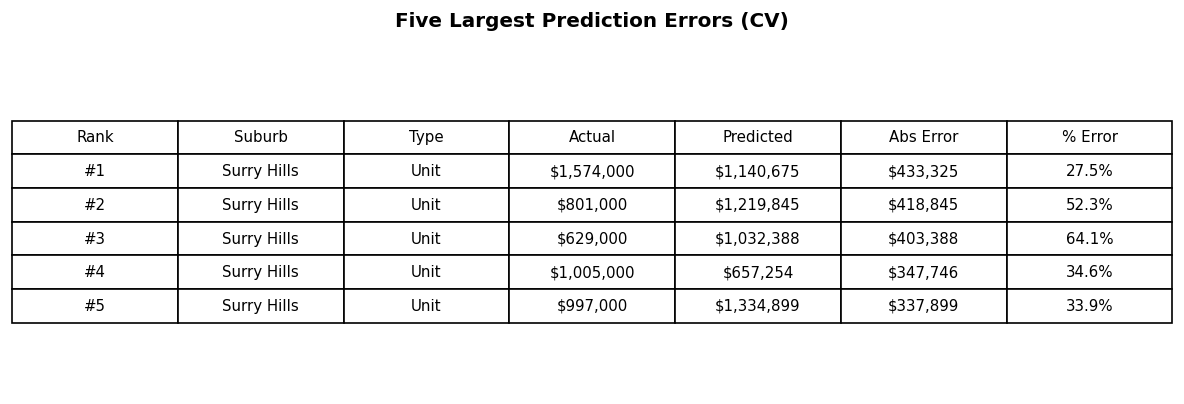

Saved: figures/top5_errors_table.png


In [6]:
# Save error table figure
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')
table_data = [
    [f'#{i}', row['suburb'], row['property_type'],
     f'${row["sale_price_aud"]:,}',
     f'${row["cv_pred_aud"]:,.0f}',
     f'${row["abs_error_aud"]:,.0f}',
     f'{row["pct_error"]}%']
    for i, row in top5_errors.iterrows()
]
cols = ['Rank', 'Suburb', 'Type', 'Actual', 'Predicted', 'Abs Error', '% Error']
tbl = ax.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
ax.set_title('Five Largest Prediction Errors (CV)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES / 'top5_errors_table.png', bbox_inches='tight')
plt.show()
print('Saved: figures/top5_errors_table.png')

---
## Summary

The five largest errors share a common root cause: the absence of qualitative property attributes. Renovation quality, condition, and agent-signalled distress sales account for most large residuals. The model performs better on typical, well-described properties in all three suburbs. The analysis strongly motivates future work incorporating structured NLP features from agent descriptions.